In [1]:
import pandas as pd

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

Orders shape: (508, 11)
Products shape: (31, 5)


In [2]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [3]:
orders.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [5]:
orders["status"].value_counts().reset_index()

,status,count
0,Delivered,439
1,Cancelled,43
2,Pending,26


## Task 1 — Initial Inspection Findings

The raw `orders_raw.csv` data contains more than 500 rows, indicating that duplicate order records are present. The `city` and `category` columns contain inconsistent casing and/or whitespace that needs to be cleaned. The `amount_inr` column contains missing values, which must be excluded from revenue calculations rather than replaced with zero or an average. There are also some suspiciously large `amount_inr` values that need to be investigated using the IQR outlier method. The `rating` column contains null values for Cancelled and Pending orders; these are legitimate because only Delivered orders receive ratings, so they should be left unchanged.

In [6]:
print("Rows before removing duplicates:", len(orders))
print("Duplicate order_id rows:", orders["order_id"].duplicated().sum())

Rows before removing duplicates: 508
Duplicate order_id rows: 8


In [7]:
rows_before = len(orders)

orders = orders.drop_duplicates(subset="order_id", keep="first").copy()

rows_after = len(orders)
rows_removed = rows_before - rows_after

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_removed)

Rows before: 508
Rows after: 500
Rows removed: 8


In [8]:
print("Final row count:", len(orders))

Final row count: 500


In [9]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("Cities:")
print(sorted(orders["city"].dropna().unique()))

print("\nCategories:")
print(sorted(orders["category"].dropna().unique()))

Cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [10]:
print("Number of distinct cities:", orders["city"].nunique())
print("Number of distinct categories:", orders["category"].nunique())

Number of distinct cities: 4
Number of distinct categories: 6


In [15]:
print("Missing amount_inr:", orders["amount_inr"].isna().sum())

print("Missing rating by status:")
print(orders.groupby("status")["rating"].apply(lambda x: x.isna().sum()))

Missing amount_inr: 10
Missing rating by status:
status
Cancelled    42
Delivered     0
Pending      24
Name: rating, dtype: int64


## Task 4 — Missing Value Handling

There are 10 missing values in `amount_inr`. These rows will be excluded from all revenue calculations because a missing revenue value is unknown and should not be treated as zero or replaced with an average.

The `rating` column has 42 null values for Cancelled orders and 24 null values for Pending orders, while Delivered orders have no missing ratings. These null ratings are legitimate because only Delivered orders receive ratings. Therefore, the null `rating` values will be left unchanged and will not be treated as a data-quality problem.

In [16]:
delivered_amounts = orders.loc[
    (orders["status"] == "Delivered") & 
    (orders["amount_inr"].notna()),
    "amount_inr"
]

print("Delivered non-null amount rows:", len(delivered_amounts))

Delivered non-null amount rows: 425


In [17]:
Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)

IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5


In [18]:
outlier_count = (
    (orders["status"] == "Delivered") &
    (orders["amount_inr"].notna()) &
    (orders["amount_inr"] > upper_fence)
).sum()

print("Number of outliers above the upper fence:", outlier_count)

Number of outliers above the upper fence: 16


In [19]:
delivered_mask = (
    (orders["status"] == "Delivered") &
    (orders["amount_inr"].notna())
)

orders.loc[delivered_mask, "amount_inr"] = (
    orders.loc[delivered_mask, "amount_inr"]
    .clip(upper=upper_fence)
)

print("Outliers capped:", outlier_count)
print("Upper fence used for capping:", upper_fence)

Outliers capped: 16
Upper fence used for capping: 552.5


## Task 5 — IQR Outlier Detection and Capping

For Delivered orders with non-null `amount_inr`, the 25th percentile (Q1), 75th percentile (Q3), IQR, and upper fence were calculated using the IQR method.

Values above the upper fence were treated as outliers. Instead of removing these orders, the outlier values were capped at the upper-fence value using `.clip(upper=...)`. This preserves the orders while reducing the effect of unusually large revenue values on the analysis.

In [21]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.month
orders["month_name"] = orders["order_date"].dt.month_name()

orders["revenue_per_unit"] = orders["amount_inr"] / orders["quantity"]

orders["is_delivered"] = orders["status"] == "Delivered"

print(orders[[
    "order_date",
    "month",
    "month_name",
    "amount_inr",
    "quantity",
    "revenue_per_unit",
    "status",
    "is_delivered"
]].head())

  order_date  month month_name  amount_inr  quantity  revenue_per_unit  \
0 2026-03-09      3      March       175.0         5              35.0   
1 2026-05-22      5        May        60.0         1              60.0   
2 2026-06-30      6       June       150.0         2              75.0   
3 2026-03-01      3      March        30.0         1              30.0   
4 2026-04-05      4      April       220.0         2             110.0   

      status  is_delivered  
0  Delivered          True  
1  Delivered          True  
2  Delivered          True  
3  Delivered          True  
4  Delivered          True  


In [22]:
category_revenue = (
    orders.loc[
        (orders["is_delivered"]) &
        (orders["amount_inr"].notna())
    ]
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64


In [23]:
orders_products = pd.merge(
    orders,
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)

print(orders_products[["order_id", "product_id", "category", "supplier", "amount_inr"]].head())

   order_id  product_id              category                supplier  \
0         1          13    Snacks & Beverages      BakeHouse Supplies   
1         2          15    Snacks & Beverages      BakeHouse Supplies   
2         3          25  Household Essentials  HomeEssentials Traders   
3         4          11    Snacks & Beverages          SnackHub India   
4         5          14    Snacks & Beverages          SnackHub India   

   amount_inr  
0       175.0  
1        60.0  
2       150.0  
3        30.0  
4       220.0  


In [24]:
supplier_revenue = (
    orders_products.loc[
        (orders_products["is_delivered"]) &
        (orders_products["amount_inr"].notna())
    ]
    .groupby("supplier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(supplier_revenue)

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64


In [25]:
top_category = category_revenue.index[0]
top_category_revenue = category_revenue.iloc[0]

top_supplier = supplier_revenue.index[0]
top_supplier_revenue = supplier_revenue.iloc[0]

print("Top category:", top_category)
print("Top category revenue:", top_category_revenue)

print("Top supplier:", top_supplier)
print("Top supplier revenue:", top_supplier_revenue)

Top category: Household Essentials
Top category revenue: 20910.0
Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0


## Task 7(c) — Cross-Validation with Part 1 SQL

The independently cleaned Pandas analysis agrees with the Part 1 SQL diagnostic on the key business findings.

- **Top category:** Household Essentials — matches Part 1.
- **Top supplier:** HomeEssentials Traders — matches Part 1.

The exact revenue totals differ from Part 1 because Part 4 starts from the raw data and applies independent cleaning steps, including duplicate removal, exclusion of missing `amount_inr` values, and IQR-based capping of high-value orders. The important cross-validation result is that the top category and top supplier remain the same.

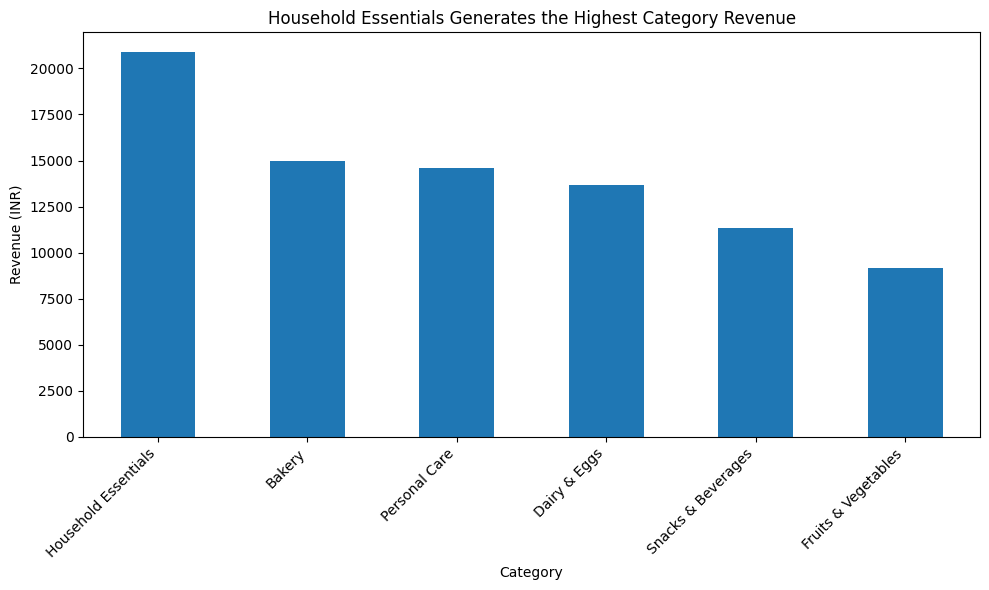

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Household Essentials Generates the Highest Category Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [27]:
monthly_revenue = (
    orders.loc[
        (orders["is_delivered"]) &
        (orders["amount_inr"].notna())
    ]
    .groupby("month_name")["amount_inr"]
    .sum()
)

month_order = [
    "January", "February", "March",
    "April", "May", "June"
]

monthly_revenue = monthly_revenue.reindex(month_order)

print(monthly_revenue)

month_name
January     10059.5
February    13715.0
March       14747.5
April       16558.5
May         16668.5
June        12888.0
Name: amount_inr, dtype: float64


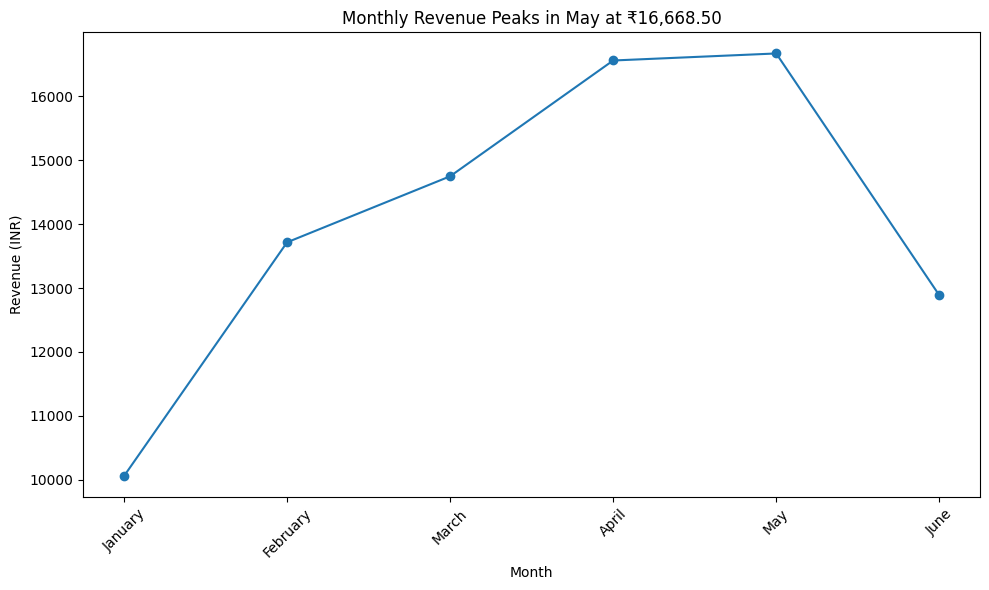

In [28]:
plt.figure(figsize=(10, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Peaks in May at ₹16,668.50")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

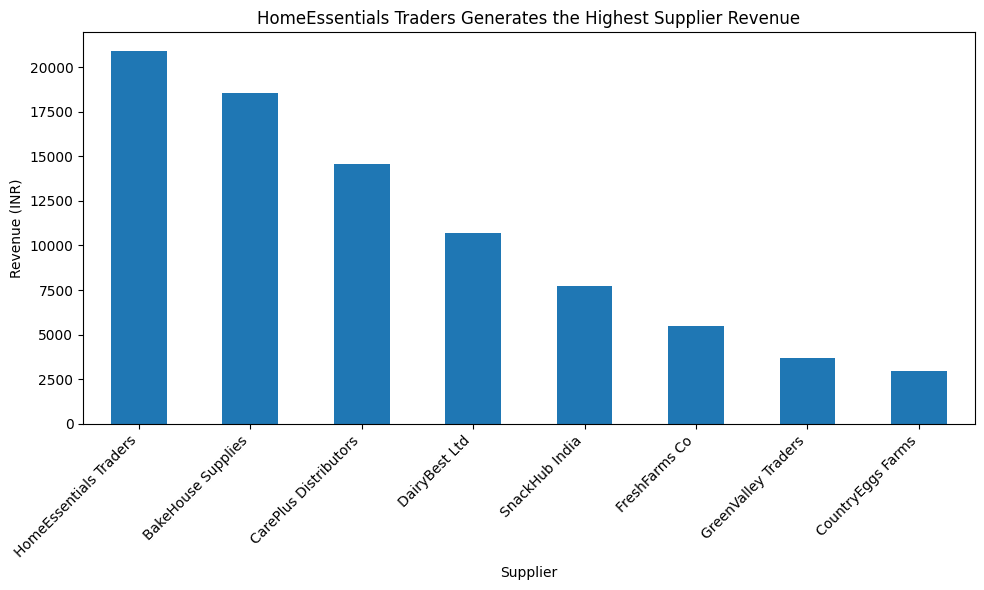

In [29]:
plt.figure(figsize=(10, 6))

supplier_revenue.plot(kind="bar")

plt.title("HomeEssentials Traders Generates the Highest Supplier Revenue")
plt.xlabel("Supplier")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 9 — Key Observations

### Observation 1 — Category Performance

**What:** Household Essentials generated the highest cleaned Delivered revenue at ₹20,910.00.

**Why it matters:** It was the strongest-performing category in the cleaned Pandas analysis and also remained the top category after data cleaning.

**Next step:** The business should investigate what is driving the strong performance of Household Essentials and look for ways to maintain it.

### Observation 2 — Monthly Revenue Trend

**What:** Monthly Delivered revenue increased from ₹10,059.50 in January to a peak of ₹16,668.50 in May, before falling to ₹12,888.00 in June.

**Why it matters:** The data shows strong revenue growth through May followed by a noticeable decline in June.

**Next step:** The business should investigate the reasons for the June decline and determine whether the pattern is temporary or requires corrective action.

### Observation 3 — Supplier Performance

**What:** HomeEssentials Traders generated the highest cleaned Delivered revenue among suppliers at ₹20,910.00.

**Why it matters:** HomeEssentials Traders was the strongest supplier in the cleaned analysis and contributed the largest supplier revenue.

**Next step:** The business should examine the products and sales factors behind this supplier's strong performance and consider maintaining a strong relationship with the supplier.

In [30]:
print("Final shape:", orders.shape)

print("\nFinal columns:")
print(orders.columns.tolist())

Final shape: (500, 15)

Final columns:
['order_id', 'order_date', 'customer_name', 'city', 'category', 'product_id', 'quantity', 'amount_inr', 'payment_mode', 'status', 'rating', 'month', 'month_name', 'revenue_per_unit', 'is_delivered']


In [31]:
print("Rows:", len(orders))
print("Distinct cities:", orders["city"].nunique())
print("Distinct categories:", orders["category"].nunique())
print("Missing amount_inr:", orders["amount_inr"].isna().sum())
print("Delivered orders:", orders["is_delivered"].sum())
print("Missing ratings in Delivered orders:",
      orders.loc[orders["is_delivered"], "rating"].isna().sum())

Rows: 500
Distinct cities: 4
Distinct categories: 6
Missing amount_inr: 10
Delivered orders: 434
Missing ratings in Delivered orders: 0


In [32]:
print("IQR Verification")
print("----------------")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)
print("Rows capped:", outlier_count)

IQR Verification
----------------
Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5
Rows capped: 16
